# Fusion des données pour la création de data set

## Imports & variables

In [26]:
import pandas as pd
from scipy.spatial import cKDTree
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os


fichier_meteo = "../data/extraction/meteo.csv"
fichier_etp = "../data/extraction/etp.csv"
dossier_nappe = "../data/extraction/nappes/"

output_folder = "../data/fusion"

## Chargement des données météos

In [3]:
meteo = pd.read_csv(fichier_meteo, sep=";")

meteo = meteo[["AAAAMM", "RR", "TMM", "ETP","LAT","LON"]]
meteo = meteo.rename(columns={
    "AAAAMM": "time",
    "RR": "PRELIQ_Q",
    "TMM": "T_Q",
    "LAT": "lat",
    "LON": "lon"
})

meteo["time"] = pd.to_datetime(meteo["time"].astype(str), format="%Y%m")

meteo_month = meteo.sort_values("time").reset_index(drop=True)
print(meteo_month.head())

        time  PRELIQ_Q  T_Q  ETP        lat       lon
0 1871-12-01       NaN  NaN  NaN  47.591667  2.753333
1 1871-12-01       NaN  NaN  NaN  47.993833  2.735333
2 1871-12-01       NaN  NaN  NaN  47.885000  2.445000
3 1871-12-01       NaN  NaN  NaN  47.856667  2.573333
4 1871-12-01       NaN  NaN  NaN  48.038333  3.060000


## Chargement des données d'évapotranspiration

In [7]:
etp = pd.read_csv(fichier_etp, sep=";")

# Conversion date (format 19700101)
etp["time"] = pd.to_datetime(etp["DATE"].astype(str), format="%Y%m%d")

etp = etp.rename(columns={
    "lat_dg": "lat",
    "lon_dg": "lon"
})

# Passage en mois
etp["month"] = etp["time"].dt.to_period("M")

# Agrégation mensuelle par maille (lat/lon)
etp_month = etp.groupby(["lat", "lon", "month"]).agg({
    "ETP_Q_H0175": "sum"   # ETP mensuelle = somme des jours
}).reset_index()

# Revenir en datetime
etp_month["time"] = etp_month["month"].dt.to_timestamp()

# Nettoyage
etp_month = etp_month.drop(columns=["month"])

print(etp_month.head())


      lat      lon  ETP_Q_H0175       time
0  47.454  1.54152       10.788 1970-01-01
1  47.454  1.54152       18.924 1970-02-01
2  47.454  1.54152       34.758 1970-03-01
3  47.454  1.54152       55.556 1970-04-01
4  47.454  1.54152      100.874 1970-05-01


## Fusion

In [52]:
os.makedirs(output_folder, exist_ok=True)

def nearest_point_valid(df_points, df_target, value_column):
    """
    Trouve pour chaque point cible le point le plus proche
    parmi ceux qui ont une valeur valide dans value_column.
    """
    # Garder seulement les points avec données
    df_valid = df_points.dropna(subset=[value_column])
    
    # S'il n'y a aucune donnée disponible
    if len(df_valid) == 0:
        return None, None
    
    tree = cKDTree(df_valid[["lat", "lon"]].values)
    _, idx = tree.query(df_target[["lat", "lon"]].values)
    
    return df_valid, idx


# Boucle sur tous les fichiers CSV de nappes
for fichier in os.listdir(dossier_nappe):
    if not fichier.endswith(".csv"):
        continue
    
    print("Traitement :", fichier)
    nappe = pd.read_csv(os.path.join(dossier_nappe, fichier), sep=";")
    
    # Préparer les données de nappe
    nappe = nappe.rename(columns={"date_mesure": "time"})
    nappe["time"] = pd.to_datetime(nappe["time"])
    nappe["month"] = nappe["time"].dt.to_period("M")
    
    nappe_month = nappe.groupby(["code_bss", "month"]).agg({
        "niveau_nappe_eau": "mean",
        "lon": "first",
        "lat": "first"
    }).reset_index()
    
    nappe_month["time"] = nappe_month["month"].dt.to_timestamp()
    nappe_month = nappe_month.drop(columns="month")
    
    # Initialiser colonnes ETP et météo
    nappe_month["ETP_Q_H0175"] = np.nan
    nappe_month["PRELIQ_Q"] = np.nan
    nappe_month["T_Q"] = np.nan
    
    # Fusion pour chaque date
    dates = nappe_month["time"].unique()
    for d in dates:
        mask = nappe_month["time"] == d
        df_day = nappe_month[mask]
        
        etp_day = etp_month[etp_month["time"] == d]
        meteo_day = meteo_month[meteo_month["time"] == d]

        if len(meteo_day) == 0:
            print("Pas de météo pour :", d)
        
        # Fusion ETP
        if len(etp_day) > 0:
            df_valid, idx_etp = nearest_point_valid(etp_day, df_day, "ETP_Q_H0175")
            if df_valid is not None:
                nappe_month.loc[mask, "ETP_Q_H0175"] = df_valid.iloc[idx_etp]["ETP_Q_H0175"].values
        
        # Fusion Météo
        if len(meteo_day) > 0:
            df_valid, idx_met = nearest_point_valid(meteo_day, df_day, "PRELIQ_Q")
            if df_valid is not None:
                nappe_month.loc[mask, "PRELIQ_Q"] = df_valid.iloc[idx_met]["PRELIQ_Q"].values
            df_valid, idx_met = nearest_point_valid(meteo_day, df_day, "T_Q")
            if df_valid is not None:
                nappe_month.loc[mask, "T_Q"] = df_valid.iloc[idx_met]["T_Q"].values
    
    # Déterminer le nom de sortie (code BSS du fichier)
    nom_nappe = nappe_month["code_bss"].iloc[0].replace("/", "_")   # supposé unique par fichier
    output_file = f"data_{nom_nappe}.csv"
    
    # Sauvegarde
    nappe_month.to_csv(os.path.join(output_folder, output_file), sep=";", index=False)


Traitement : nappe_02927X1013_P.csv
Traitement : nappe_02928X1008_P.csv
Traitement : nappe_02928X1014_P.csv
Traitement : nappe_02935X1019_P.csv
Traitement : nappe_02936X1018_P.csv
Traitement : nappe_02936X2005_PFAEP.csv
Traitement : nappe_03273X0022_S1.csv
Traitement : nappe_03273X0026_P.csv
Traitement : nappe_03273X0032_S1.csv
Traitement : nappe_03276X0009_P.csv
Traitement : nappe_03276X0057_P.csv
Traitement : nappe_03277X0019_S1.csv
Traitement : nappe_03277X0059_S1.csv
Traitement : nappe_03278X0020_P.csv
Traitement : nappe_03281X0015_P.csv
Traitement : nappe_03281X0019_P.csv
Traitement : nappe_03282X0029_P.csv
Traitement : nappe_03282X0043_S1.csv
Traitement : nappe_03283X0018_P.csv
Traitement : nappe_03283X0020_P.csv
Traitement : nappe_03283X0057_F.csv
Traitement : nappe_03283X0060_F.csv
Traitement : nappe_03284X0012_P1.csv
Traitement : nappe_03284X0014_S1.csv
Traitement : nappe_03285X0032_P.csv
Traitement : nappe_03286X0031_P.csv
Traitement : nappe_03287X0018_S1.csv
Traitement : nap

KeyboardInterrupt: 

## Visualisation

Analyse des fichiers...
Shape : (28, 8)


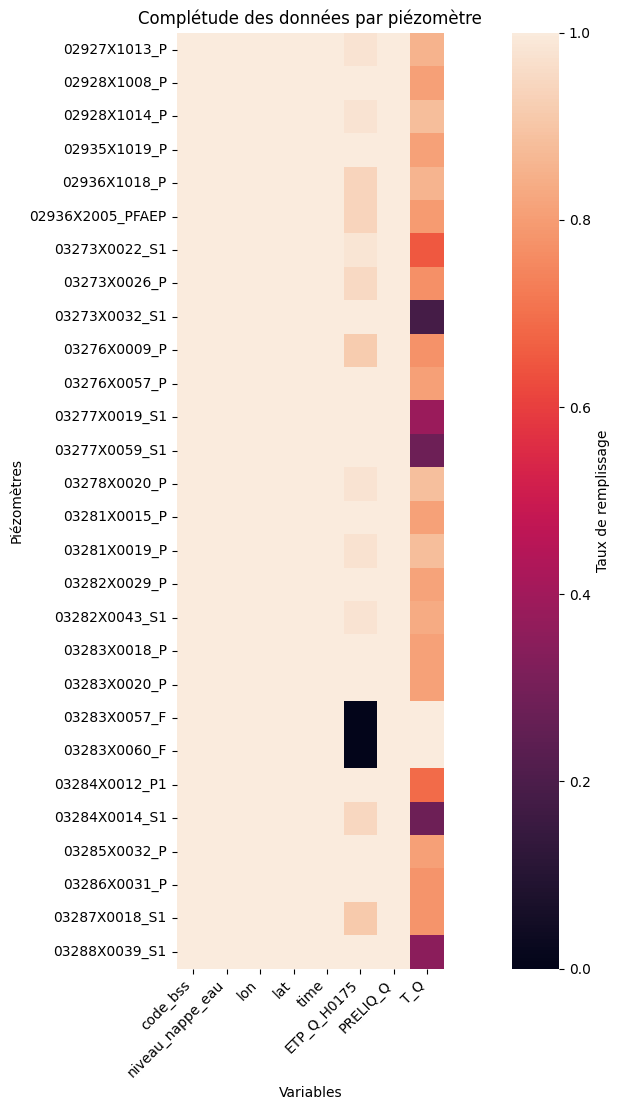

In [53]:
# Dossier contenant tes fichiers
folder = output_folder

results = []

print("Analyse des fichiers...")

for file in os.listdir(folder):
    if not file.endswith(".csv"):
        continue
    
    path = os.path.join(folder, file)
    df = pd.read_csv(path, sep=";")
    
    if len(df) == 0:
        continue
    
    total_rows = len(df)
    
    # Taux de remplissage par colonne
    fill_ratio = df.notna().sum() / total_rows
    
    fill_ratio["file"] = file.replace("data_", "").replace(".csv", "")
    results.append(fill_ratio)

# Construire la matrice
heat_df = pd.DataFrame(results)
heat_df = heat_df.set_index("file")
heat_df = heat_df.sort_index()

print("Shape :", heat_df.shape)

plt.figure(figsize=(14, max(6, len(heat_df) * 0.4)))

sns.heatmap(
    heat_df,
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Taux de remplissage"}
)

plt.title("Complétude des données par piézomètre")
plt.xlabel("Variables")
plt.ylabel("Piézomètres")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()
